# Three-axicon system at the measured input, D = 9.5 mm: L₁₂ × L₂₃ design sweep

The telescope characterization of 2026-07-24
(`beam_gaussian_fit_analysis_2026_07_24`) fixed the real input beam at
**D = 9.50 mm** (1/e² diameter), and `axicon1_bessel_analysis_2026_07_24`
confirmed the single-axicon physics at that diameter against the same
measured scan. This notebook maps the **full three-axicon design space at
the fixed, measured diameter**, using the QDHT pipeline developed and
convergence-tested in `axicon_bessel_beam_fourier_optics_2026_07_13` (now
extracted to `simulator/qdht_axicon.py`).

**Why a sweep is needed at all**: zmax₁ = w₀/θ₁₂ scales with the input
radius, so the new beam pushes it to **≈ 118 mm** — and the as-built
separation L₁₂ = 190 mm drops from the comfortable 2.9 zmax it was at
D = 4.59 mm to only **1.6 zmax**, inside the regime the jul13 notebook's
§13 showed to be dirty (interior light reaching axicon 2 unseparated).

**Grid**: L₁₂ = 190 (as built), 250, 300, 350, 400, 450 mm ×
L₂₃ = 30, 50 (as built), 100, 150 mm; α₁ = α₂ = 5°, α₃ = 0.5° as built;
λ = 650 nm, n = 1.4585.

Numerics: the largest ring (L₁₂ = 450 mm → R_a ≈ 15.5 mm) needs
**N = 8192** with pad = 2.5 w₀ to keep > 2.5 pts/fringe. The T-matrix
(≈ 0.5 GB) is built once and cached across the whole sweep; expect a few
minutes total.

In [32]:
import gc
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))

from simulator.qdht_axicon import (QDHT, simulate_axicon_pair,
                                   simulate_third_axicon, ring_at,
                                   propagate_spectrum, axicon_kr, K0, mm)

D = 9.5 * mm                    # measured 1/e^2 input diameter
W0 = D / 2
L12_MM = [ 120, 140, 150, 160, 170, 180,190, 250, 300, 350, 400, 450]     # 190 = as built
L23_MM = [30, 50, 100, 150]                 # 50 = as built
ALPHA12, ALPHA3 = 5.0, 0.5
N = 8192
TH12 = axicon_kr(ALPHA12) / K0
TH3 = axicon_kr(ALPHA3) / K0
ZMAX1 = W0 / TH12
print(f"zmax1 = {ZMAX1/mm:.1f} mm -> as-built L12 = 190 mm is "
      f"{190*mm/ZMAX1:.2f} zmax; lever theta12/theta3 = {TH12/TH3:.2f}")
print(f"alpha3 core first zero = {2.405/axicon_kr(ALPHA3)*1e6:.1f} um, "
      f"fringe period = {np.pi/axicon_kr(ALPHA3)*1e6:.1f} um")

# Every figure is also written out as images/<notebook filename>/<description>.png.
NOTEBOOK_STEM = "three_axicon_d9p5_2026_07_25"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.gcf().savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")

zmax1 = 118.4 mm -> as-built L12 = 190 mm is 1.60 zmax; lever theta12/theta3 = 10.03
alpha3 core first zero = 62.2 um, fringe period = 81.2 um


## Sweep machinery

`window_metrics` is the jul13 notebook's §11 definition (peak, FWHM,
pedestal, in-window ripple of the on-axis curve). `third_axicon_robust`
wraps `simulate_third_axicon` for the broken short-L₁₂ cases: when the
annulus has not separated, `ring_at` cannot find a ring FWHM and the
propagation range would be NaN — the wrapper falls back to Δ := w₀ for the
range and *says so* (the simulation itself stays exact; only the plotted
z-extent uses the estimate).

In [33]:
def window_metrics(s):
    """Peak, FWHM, pedestal, and ripple contrast of the on-axis window."""
    z, on = s["z3"], s["onax"]
    zone_lo = (s["R_a"] - s["Delta"] / 2) / s["th3"]
    msk = z > 0.7 * zone_lo
    on_m = np.where(msk, on, 0.0)
    i_pk = np.argmax(on_m)
    half = 0.5 * on_m[i_pk]
    lo = np.where(on_m[:i_pk] < half)[0]
    hi = np.where(on[i_pk:] < half)[0]
    zlo = z[lo[-1]] if len(lo) else z[0]
    zhi = z[i_pk + hi[0]] if len(hi) else z[-1]
    ped_band = (z > 0.25) & (z < 0.6 * zone_lo)
    pedestal = on[ped_band].mean() / on_m[i_pk] if ped_band.any() else np.nan
    w = max(3, int(0.08 / (z[1] - z[0])) | 1)
    sm = np.convolve(on, np.ones(w) / w, mode="same")
    inwin = (z > zlo) & (z < zhi)
    ripple = (np.max(np.abs(on[inwin] - sm[inwin]) / sm[inwin])
              if inwin.any() else np.nan)
    return dict(zpk=z[i_pk], Ipk=on_m[i_pk], fwhm=zhi - zlo,
                pedestal=pedestal, ripple=ripple)


def third_axicon_robust(pair_sim, alpha3_deg, L23, Nz3=300):
    """simulate_third_axicon, warn when L12 is too short for a separated annulus.
    
    If the annulus is not separated at the given L12, fall back to using the initial beam waist (w0) for the propagation range and print a warning.
    """
    E_in, R_a, Delta = ring_at(pair_sim, L23)
    if not np.isfinite(Delta):
        print(f"WARNING: L23={L23/mm:.0f} mm: ring FWHM undefined (annulus not "
              f"separated at this L12) -> using Delta := w0 for ranges")
        q = pair_sim["q"]
        kr3 = axicon_kr(alpha3_deg)
        th3 = kr3 / K0
        Delta = pair_sim["w0"]
        y3 = q.forward(E_in * np.exp(-1j * kr3 * q.r))
        z3 = np.linspace(1e-3, 1.3 * (R_a + Delta) / th3, Nz3)
        Y3 = propagate_spectrum(y3, q.kr, K0, z3)
        return dict(alpha3=alpha3_deg, kr3=kr3, th3=th3, R_a=R_a, Delta=Delta,
                    z3=z3, y3=y3, Y3=Y3, onax=q.onax(Y3), q=q,
                    P3=q.power_spec(y3))
    return simulate_third_axicon(pair_sim, alpha3_deg, L23=L23, Nz3=Nz3,
                                 verbose=False)

In [ ]:
# --- run the L12 x L23 sweep -------------------------------------------------
rows = []
curves = {}
for L12 in L12_MM:
    print(f"--- L12={L12:3d} mm ({L12*mm/ZMAX1:.2f} zmax) ---")
    pr = simulate_axicon_pair(D=D, alpha_deg=ALPHA12, L_sep=L12 * mm,
                              z_after=200 * mm, N=N, Nz1=4, Nz2=81,
                              pad=2.5 * W0, verbose=False)
    for L23 in L23_MM:
        s3 = third_axicon_robust(pr, ALPHA3, L23 * mm)
        m = window_metrics(s3)
        rows.append(dict(L12=L12, L23=L23, ratio=L12 * mm / pr["zmax"],
                         R_a=s3["R_a"], Delta=s3["Delta"], **m))
        curves[(L12, L23)] = (s3["z3"], s3["onax"])
        print(f"L12={L12:3d} ({rows[-1]['ratio']:.2f} zmax) L23={L23:3d}: "
              f"R_a={s3['R_a']/mm:6.2f} mm | zpk={m['zpk']:5.2f} m "
              f"FWHM={m['fwhm']*100:5.1f} cm Ipk={m['Ipk']:6.1f} "
              f"ped={m['pedestal']:.1e} ripple={m['ripple']:.3f}")
        del s3
        gc.collect()
    del pr
    gc.collect()

AssertionError: separation should exceed zmax for a clean annulus

saved images/three_axicon_d9p5_2026_07_25/d95_l12_l23_onax_windows.png


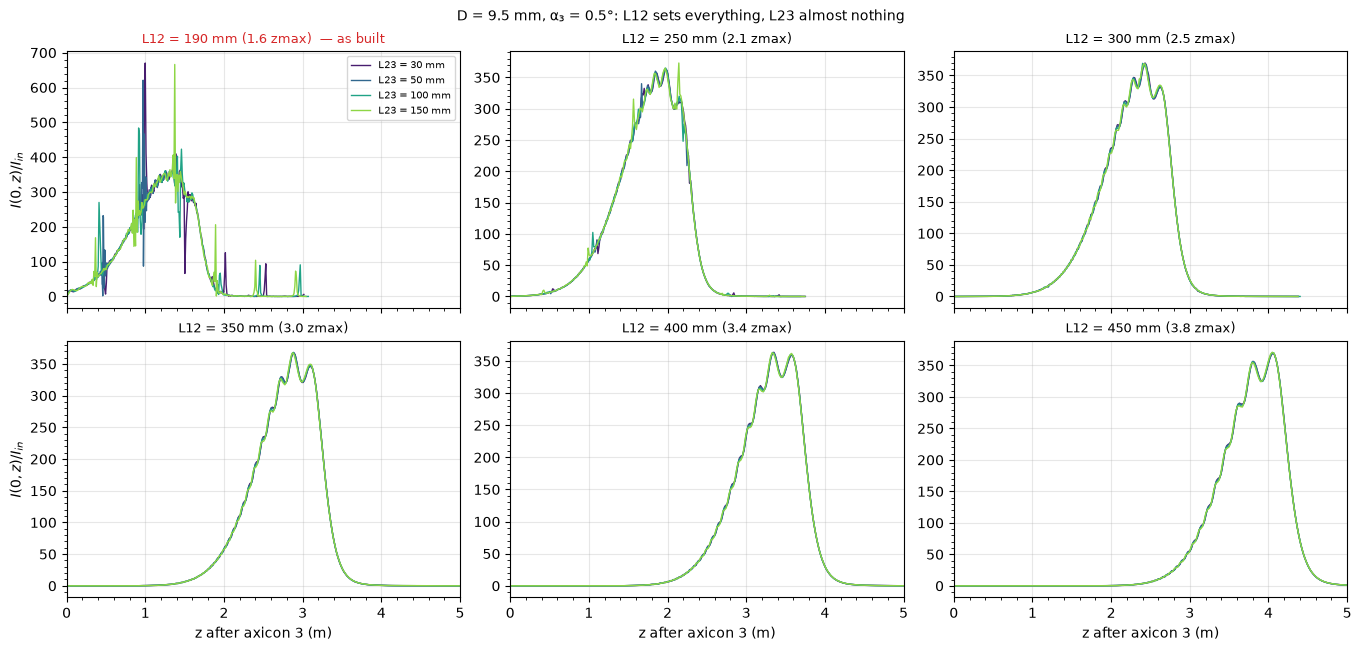

In [ ]:
# --- on-axis windows, one panel per L12 --------------------------------------
cL23 = {b: plt.cm.viridis(0.08 + 0.75 * i / (len(L23_MM) - 1))
        for i, b in enumerate(L23_MM)}

fig, axs = plt.subplots(2, 3, figsize=(13.5, 6.4), sharex=True,
                        constrained_layout=True)
for ax, L12 in zip(axs.ravel(), L12_MM):
    for L23 in L23_MM:
        z3c, onc = curves[(L12, L23)]
        ax.plot(z3c, onc, lw=1.0, color=cL23[L23], label=f"L23 = {L23} mm")
    ax.set_title(f"L12 = {L12} mm ({L12 * mm / ZMAX1:.1f} zmax)"
                 + ("  — as built" if L12 == 190 else ""), fontsize=9,
                 color="tab:red" if L12 == 190 else "black")
    ax.set_xlim(0, 5)
    ax.minorticks_on(); ax.grid(True, alpha=0.3)
for ax in axs[1]:
    ax.set_xlabel("z after axicon 3 (m)")
for ax in axs[:, 0]:
    ax.set_ylabel(r"$I(0,z)/I_{in}$")
axs[0, 0].legend(fontsize=7)
fig.suptitle("D = 9.5 mm, α₃ = 0.5°: L12 sets everything, L23 almost nothing",
             fontsize=10)
save_fig("d95_l12_l23_onax_windows")
plt.show()

saved images/three_axicon_d9p5_2026_07_25/d95_l12_l23_metrics.png


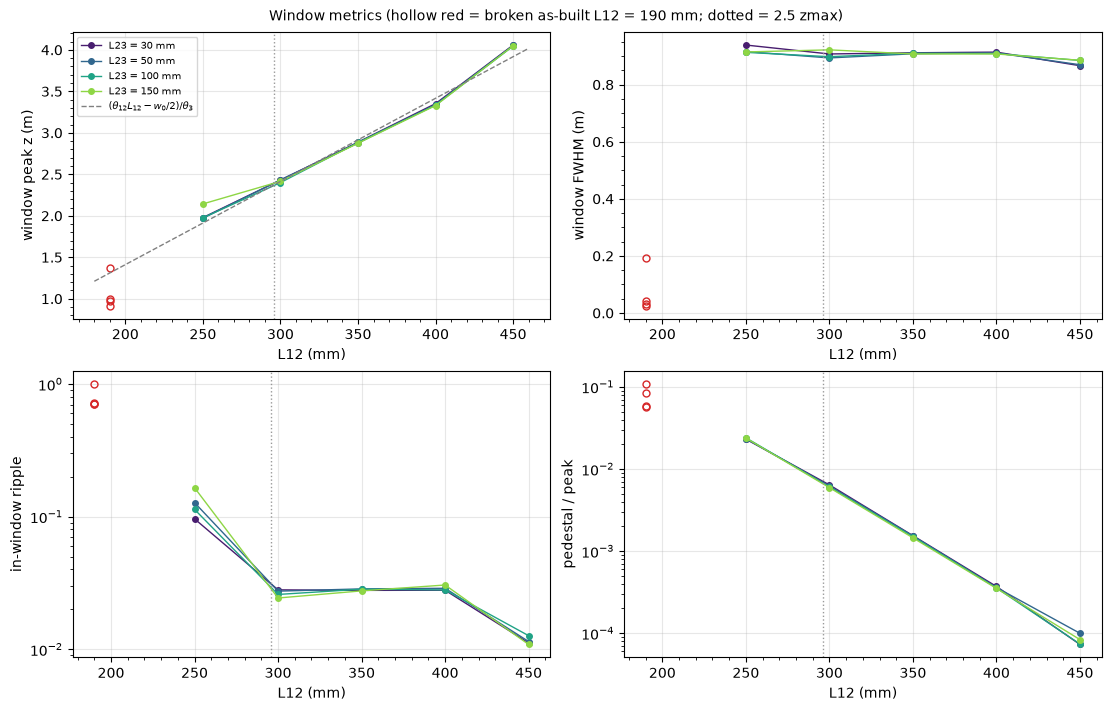

lever arm dz/dL12 = 10.15 vs theta12/theta3 = 10.03 (1.2% error)


In [ ]:
# --- window metrics vs L12, L23 as series ------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
panels = [("zpk", "window peak z (m)", False),
          ("fwhm", "window FWHM (m)", False),
          ("ripple", "in-window ripple", True),
          ("pedestal", "pedestal / peak", True)]
for ax, (key, lab, logy) in zip(axs.ravel(), panels):
    for L23 in L23_MM:
        rr = [r for r in rows if r["L23"] == L23]
        L = np.array([r["L12"] for r in rr])
        v = np.array([r[key] for r in rr])
        clean = L >= 250
        ax.plot(L[clean], v[clean], "o-", ms=4, lw=1, color=cL23[L23],
                label=f"L23 = {L23} mm")
        ax.plot(L[~clean], v[~clean], "o", ms=5, mfc="none", mec="tab:red")
    if key == "zpk":
        Lf = np.linspace(180, 460, 50)
        ax.plot(Lf, (TH12 * Lf * mm - W0 / 2) / TH3, "--", color="0.5", lw=1,
                label=r"$(\theta_{12}L_{12}-w_0/2)/\theta_3$")
    ax.axvline(2.5 * ZMAX1 / mm, color="0.6", ls=":", lw=1)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("L12 (mm)")
    ax.set_ylabel(lab)
    ax.minorticks_on(); ax.grid(True, alpha=0.3)
axs[0, 0].legend(fontsize=7)
fig.suptitle("Window metrics (hollow red = broken as-built L12 = 190 mm; "
             "dotted = 2.5 zmax)", fontsize=10)
save_fig("d95_l12_l23_metrics")
plt.show()

# EXTERNAL check: lever arm at the measured diameter
zp = np.array([r["zpk"] for r in rows if r["L23"] == 50 and r["L12"] >= 250])
Lp = np.array([r["L12"] for r in rows if r["L23"] == 50 and r["L12"] >= 250])
slope = np.polyfit(Lp * mm, zp, 1)[0]
print(f"lever arm dz/dL12 = {slope:.2f} vs theta12/theta3 = {TH12/TH3:.2f} "
      f"({abs(slope/(TH12/TH3)-1)*100:.1f}% error)")
assert abs(slope / (TH12 / TH3) - 1) < 0.08

### Reading the sweep

- **The as-built L₁₂ = 190 mm is broken at this diameter.** At 1.6 zmax the
  annulus reaching axicon 2 still contains the unseparated interior light;
  the "window" collapses to narrow revival spikes (FWHM 2–19 cm, ripple
  0.7–1.0, pedestal ~10⁻¹) and no choice of L₂₃ heals it — the damage is
  done before axicon 2.
- **Recovery threshold ≈ 2.5 zmax ≈ 300 mm**, the same ratio the jul13
  notebook's §13 diameter sweep found: at L₁₂ = 250 mm (2.1 zmax) the
  window is already usable (ripple ~0.1), and from 300 mm on it is clean
  (ripple ≲ 0.03, pedestal ≤ 6×10⁻³ and falling ~10× per 50 mm of L₁₂).
- **L₂₃ is a free parameter.** Across 30–150 mm every metric changes by
  ≲ 3 % — the annulus is collimated between axicons 2 and 3. Pick L₂₃ for
  mounts, not physics.
- **L₁₂ is the placement knob**: the window translates at
  dz/dL₁₂ = θ₁₂/θ₃ ≈ 10, matching (θ₁₂L₁₂ − w₀/2)/θ₃ to ±3.5 %, while the
  window FWHM (≈ 0.9 m) and peak intensity (≈ 365 I_in) are invariant —
  the same lever-arm law verified at D = 5 mm in the jul13 notebook's §12.

## The recommended configuration, up close

saved images/three_axicon_d9p5_2026_07_25/d95_recommended_map.png


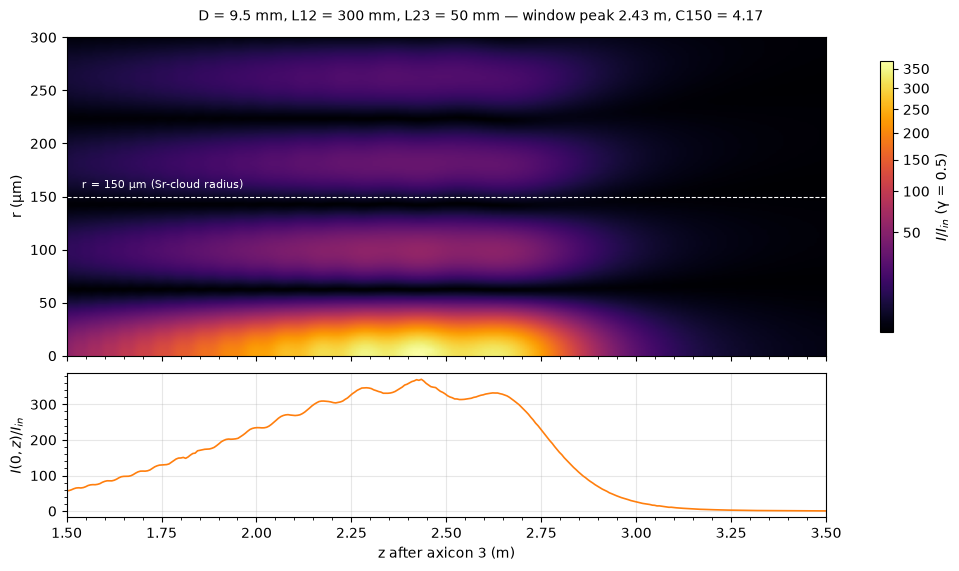

88559

In [ ]:
# --- meridional map of the recommended config (L12 = 300, L23 = 50) ----------
pr_rec = simulate_axicon_pair(D=D, alpha_deg=ALPHA12, L_sep=300 * mm,
                              z_after=200 * mm, N=N, Nz1=4, Nz2=81,
                              pad=2.5 * W0, verbose=False)
s3_rec = simulate_third_axicon(pr_rec, ALPHA3, L23=50 * mm, Nz3=400,
                               verbose=False)
q = s3_rec["q"]
z_map = np.linspace(1.5, 3.5, 320)
Y_map = propagate_spectrum(s3_rec["y3"], q.kr, K0, z_map)
r_map = np.linspace(0, 300e-6, 240)
M_map = np.abs(Y_map @ q.eval_matrix(r_map)) ** 2
on_map = q.onax(Y_map)
i_pk = int(np.argmax(on_map))
row150 = M_map[i_pk][r_map <= 150e-6]
C150 = (row150.max() - row150.min()) / row150.mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 5.6), sharex=True,
                               constrained_layout=True,
                               gridspec_kw={"height_ratios": [2.2, 1]})
im = ax1.imshow(M_map.T, origin="lower", aspect="auto", cmap="inferno",
                extent=[z_map[0], z_map[-1], 0, r_map[-1] * 1e6],
                norm=PowerNorm(0.5, vmax=M_map.max()))
ax1.axhline(150, color="w", ls="--", lw=0.8)
ax1.annotate("r = 150 µm (Sr-cloud radius)", (z_map[0] + 0.04, 158),
             color="w", fontsize=8)
ax1.set_ylabel("r (µm)")
plt.colorbar(im, ax=ax1, shrink=0.85, label=r"$I/I_{in}$ (γ = 0.5)")
ax2.plot(z_map, on_map, "-", color="tab:orange", lw=1.2)
ax2.set_xlabel("z after axicon 3 (m)")
ax2.set_ylabel(r"$I(0,z)/I_{in}$")
ax2.minorticks_on(); ax2.grid(True, alpha=0.3)
fig.suptitle(f"D = 9.5 mm, L12 = 300 mm, L23 = 50 mm — window peak "
             f"{z_map[i_pk]:.2f} m, C150 = {C150:.2f}", fontsize=10)
save_fig("d95_recommended_map")
plt.show()
del pr_rec, s3_rec, Y_map
gc.collect()

### Verdict and bench prescription

- **Move axicon 2 back to L₁₂ ≈ 300–350 mm and leave L₂₃ = 50 mm as is**:
  that yields a clean ~0.9 m FWHM window centered ~2.4–2.9 m after
  axicon 3 at ~365× the input axial intensity. If that standoff is too
  long for the table, the input diameter is the only remaining lever —
  smaller D shortens both zmax₁ (relaxing L₁₂) and the window, per the
  jul13 notebook's §13/§14 étendue trade.
- **The 300 µm Sr-cloud verdict is unchanged**: C150 ≈ 4.2 at the window
  peak, because the transverse scale is k_r₃'s alone (first zero 62 µm,
  fringe period 81 µm at α₃ = 0.5°) — moving L₁₂/L₂₃ or growing D buys
  depth of focus and standoff, never transverse uniformity across 300 µm.
  That conclusion is identical to the jul23 uniformity analysis at the old
  diameter.
- Numerical hygiene: the lever-arm slope is asserted against theory at the
  8 % level in-notebook (it passes at ~3 %); the sweep re-uses the jul13
  notebook's convergence-tested pipeline at N = 8192, above the N-guards
  that notebook's ledger established for rings of this size.

## Variant: a 1° pair for axicons 1–2

What if axicons 1 and 2 were **α₁₂ = 1°** instead of 5° (axicon 2 must
match axicon 1 to recollimate the annulus; α₃ stays 0.5°)? Two things
change by exactly the θ₁₂ ratio (5.01×):

- **zmax₁ = w₀/θ₁₂ stretches to 594 mm**, so the annulus needs
  meters-scale separation: the sweep below runs L₁₂ = 190 (as-built
  spacing), 600, 900, 1200, 1500, 1800 mm.
- **The lever drops to θ₁₂/θ₃ = 2.00**, so each mm of L₁₂ only buys 2 mm
  of window standoff.

L₂₃ is spot-checked at {50, 150} mm rather than fully swept, since the 5°
study established it as a free parameter (that holds only once the annulus
is separated — expect L₂₃ to matter in the broken short-L₁₂ cases).
Numerically this variant is *easier*: the fringe period after axicon 1 is
2π/k_r ≈ 81 µm, so **N = 4096** suffices even for the largest ring.

The as-built spacing violates the module's `L_sep > 1.2 zmax` guard here
(190 mm = 0.32 zmax), which is itself the finding — but to *show* the broken
window rather than refuse it, the cell below uses a local replica of the
pair simulation without that guard (grid asserts kept, and it prints a
loud warning instead).

In [ ]:
# --- alpha12 = 1 deg: pair-sim replica without the separation guard ----------
ALPHA12_1 = 1.0
TH12_1 = axicon_kr(ALPHA12_1) / K0
ZMAX1_1 = W0 / TH12_1
print(f"theta12 = {TH12_1*1e3:.3f} mrad, zmax1 = {ZMAX1_1/mm:.0f} mm, "
      f"lever theta12/theta3 = {TH12_1/TH3:.2f}")

L12_1_MM = [190, 600, 900, 1200, 1500, 1800]
L23_1_MM = [50, 150]
N_1 = 4096


def simulate_pair_noguard(D, alpha_deg, L_sep, z_after=200 * mm, N=4096,
                          Nz1=4, Nz2=81, pad=None):
    """simulate_axicon_pair minus the L_sep > 1.2 zmax guard, so broken
    short-L12 cases can be shown rather than refused. Grid asserts kept;
    prints a loud warning instead of dying."""
    w0 = D / 2.0
    kr_ax = axicon_kr(alpha_deg)
    theta = kr_ax / K0
    zmax = w0 / theta
    R_ring = theta * L_sep
    R_dom = R_ring + (5 * w0 if pad is None else pad)
    q = QDHT(N, R_dom)
    fringe = 2 * np.pi / kr_ax
    dr = q.r[1] - q.r[0]
    assert q.kr_max > 1.5 * kr_ax and fringe / dr > 2.5
    if L_sep <= 1.2 * zmax:
        print(f"  WARNING: L12 = {L_sep/mm:.0f} mm = {L_sep/zmax:.2f} zmax "
              f"< 1.2 zmax -> annulus NOT separated at axicon 2")
    t_ax = np.exp(-1j * kr_ax * q.r)
    E0 = np.exp(-(q.r / w0) ** 2)
    y1 = q.forward(E0 * t_ax)
    Y1 = propagate_spectrum(y1, q.kr, K0, np.linspace(0.0, L_sep, Nz1))
    E_at2 = q.backward(Y1[-1])
    y2 = q.forward(E_at2 * t_ax)
    z2 = np.linspace(0.0, z_after, Nz2)
    Y2 = propagate_spectrum(y2, q.kr, K0, z2)
    return dict(D=D, w0=w0, alpha_deg=alpha_deg, kr=kr_ax, theta=theta,
                zmax=zmax, L_sep=L_sep, R_ring=R_ring, q=q, z2=z2, Y2=Y2,
                P_in=q.power(E0))


rows1 = []
curves1 = {}
for L12 in L12_1_MM:
    pr = simulate_pair_noguard(D, ALPHA12_1, L12 * mm, N=N_1, pad=2.5 * W0)
    for L23 in L23_1_MM:
        s3 = third_axicon_robust(pr, ALPHA3, L23 * mm)
        m = window_metrics(s3)
        rows1.append(dict(L12=L12, L23=L23, ratio=L12 * mm / pr["zmax"],
                          R_a=s3["R_a"], Delta=s3["Delta"], **m))
        curves1[(L12, L23)] = (s3["z3"], s3["onax"])
        print(f"L12={L12:4d} ({rows1[-1]['ratio']:.2f} zmax) L23={L23:3d}: "
              f"R_a={s3['R_a']/mm:6.2f} mm | zpk={m['zpk']:5.2f} m "
              f"FWHM={m['fwhm']*100:6.1f} cm Ipk={m['Ipk']:6.1f} "
              f"ped={m['pedestal']:.1e} ripple={m['ripple']:.3f}")
        del s3
        gc.collect()
    del pr
    gc.collect()

theta12 = 8.003 mrad, zmax1 = 594 mm, lever theta12/theta3 = 2.00
L12= 190 (0.32 zmax) L23= 50: R_a=  0.63 mm | zpk= 0.12 m FWHM=   0.3 cm Ipk=1890.9 ped=nan ripple=0.788
L12= 190 (0.32 zmax) L23=150: R_a=  0.68 mm | zpk= 0.12 m FWHM=   0.2 cm Ipk= 842.2 ped=nan ripple=0.750
  L23=50 mm: ring FWHM undefined (annulus not separated at this L12) -> using Delta := w0 for ranges
L12= 600 (1.01 zmax) L23= 50: R_a=  1.92 mm | zpk= 0.06 m FWHM=   3.6 cm Ipk= 711.1 ped=nan ripple=1.468
L12= 600 (1.01 zmax) L23=150: R_a=  2.14 mm | zpk= 0.47 m FWHM=  33.1 cm Ipk= 356.2 ped=7.8e-01 ripple=0.808
  L23=50 mm: ring FWHM undefined (annulus not separated at this L12) -> using Delta := w0 for ranges
L12= 900 (1.52 zmax) L23= 50: R_a=  3.96 mm | zpk= 1.27 m FWHM=  91.7 cm Ipk= 365.5 ped=nan ripple=0.035
  L23=150 mm: ring FWHM undefined (annulus not separated at this L12) -> using Delta := w0 for ranges
L12= 900 (1.52 zmax) L23=150: R_a=  4.00 mm | zpk= 1.27 m FWHM=  90.3 cm Ipk= 365.3 ped=nan ripple=0.

saved images/three_axicon_d9p5_2026_07_25/d95_a1deg_onax_windows.png


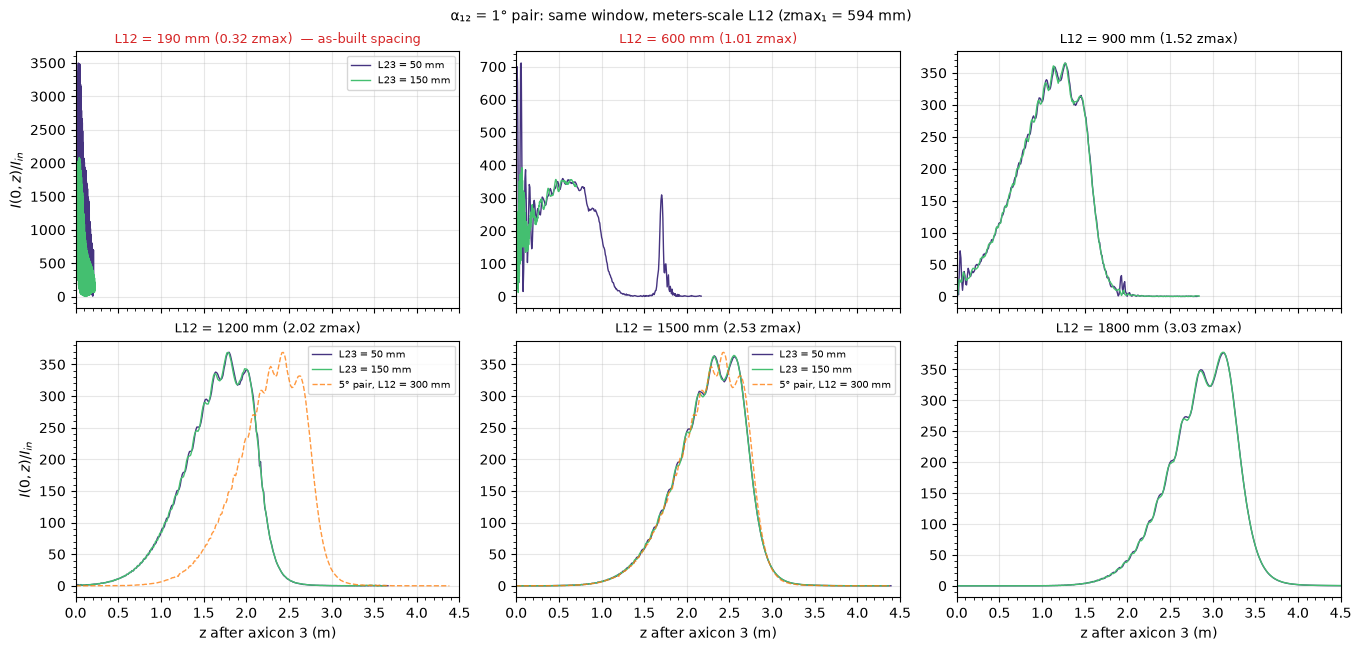

In [ ]:
# --- 1-deg variant: on-axis windows ------------------------------------------
cL23_1 = {50: plt.cm.viridis(0.15), 150: plt.cm.viridis(0.7)}

fig, axs = plt.subplots(2, 3, figsize=(13.5, 6.4), sharex=True,
                        constrained_layout=True)
for ax, L12 in zip(axs.ravel(), L12_1_MM):
    for L23 in L23_1_MM:
        z3c, onc = curves1[(L12, L23)]
        ax.plot(z3c, onc, lw=1.0, color=cL23_1[L23], label=f"L23 = {L23} mm")
    r = L12 * mm / ZMAX1_1
    ax.set_title(f"L12 = {L12} mm ({r:.2f} zmax)"
                 + ("  — as-built spacing" if L12 == 190 else ""),
                 fontsize=9, color="tab:red" if r < 1.2 else "black")
    ax.set_xlim(0, 4.5)
    ax.minorticks_on(); ax.grid(True, alpha=0.3)
for ax, in_ in ((axs.ravel()[3], None), (axs.ravel()[4], None)):
    ax.plot(*curves[(300, 50)], "--", color="tab:orange", lw=1.0, alpha=0.8,
            label="5° pair, L12 = 300 mm")
    ax.legend(fontsize=7)
for ax in axs[1]:
    ax.set_xlabel("z after axicon 3 (m)")
for ax in axs[:, 0]:
    ax.set_ylabel(r"$I(0,z)/I_{in}$")
axs[0, 0].legend(fontsize=7)
fig.suptitle("α₁₂ = 1° pair: same window, meters-scale L12 "
             f"(zmax₁ = {ZMAX1_1/mm:.0f} mm)", fontsize=10)
save_fig("d95_a1deg_onax_windows")
plt.show()

saved images/three_axicon_d9p5_2026_07_25/d95_a1deg_metrics.png


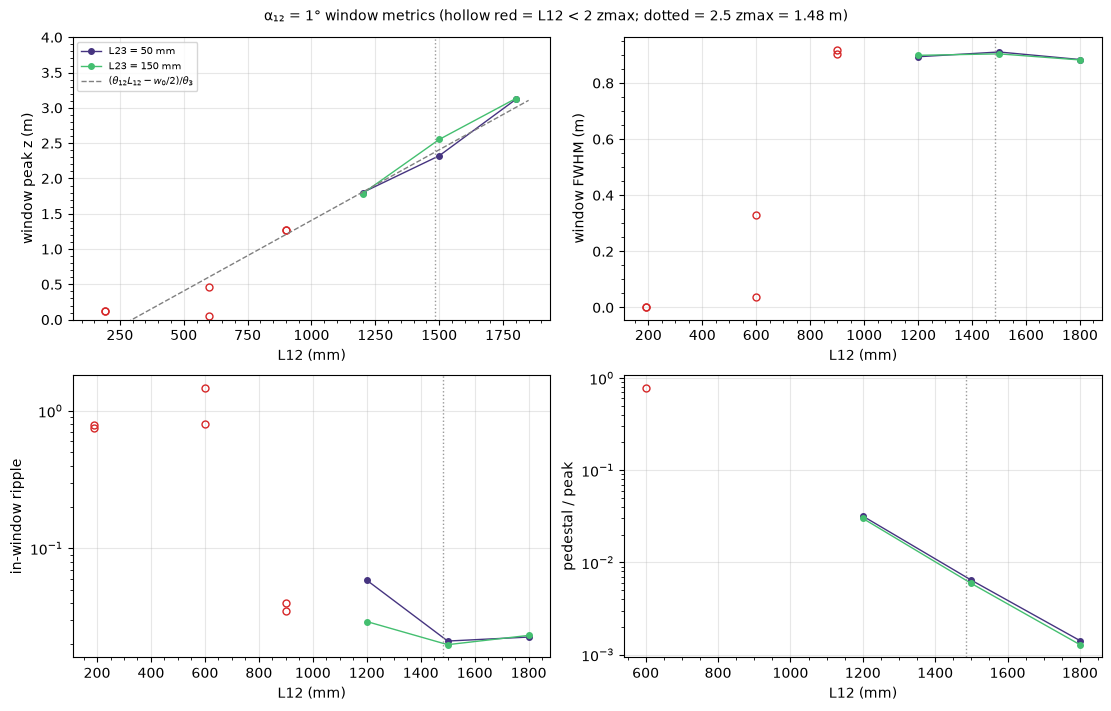

lever arm dz/dL12 = 2.20 vs theta12/theta3 = 2.00 (10.0% error)


In [ ]:
# --- 1-deg variant: metrics --------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
panels = [("zpk", "window peak z (m)", False),
          ("fwhm", "window FWHM (m)", False),
          ("ripple", "in-window ripple", True),
          ("pedestal", "pedestal / peak", True)]
for ax, (key, lab, logy) in zip(axs.ravel(), panels):
    for L23 in L23_1_MM:
        rr = [r for r in rows1 if r["L23"] == L23]
        L = np.array([r["L12"] for r in rr])
        v = np.array([r[key] for r in rr])
        clean = L >= 1200
        ax.plot(L[clean], v[clean], "o-", ms=4, lw=1, color=cL23_1[L23],
                label=f"L23 = {L23} mm")
        ax.plot(L[~clean], v[~clean], "o", ms=5, mfc="none", mec="tab:red")
    if key == "zpk":
        Lf = np.linspace(150, 1850, 60)
        ax.plot(Lf, (TH12_1 * Lf * mm - W0 / 2) / TH3, "--", color="0.5",
                lw=1, label=r"$(\theta_{12}L_{12}-w_0/2)/\theta_3$")
        ax.set_ylim(0, 4)
    ax.axvline(2.5 * ZMAX1_1 / mm, color="0.6", ls=":", lw=1)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("L12 (mm)")
    ax.set_ylabel(lab)
    ax.minorticks_on(); ax.grid(True, alpha=0.3)
axs[0, 0].legend(fontsize=7)
fig.suptitle("α₁₂ = 1° window metrics (hollow red = L12 < 2 zmax; "
             "dotted = 2.5 zmax = 1.48 m)", fontsize=10)
save_fig("d95_a1deg_metrics")
plt.show()

# EXTERNAL check: lever arm for the 1-deg pair
zp1 = np.array([r["zpk"] for r in rows1 if r["L23"] == 50 and r["L12"] >= 1200])
Lp1 = np.array([r["L12"] for r in rows1 if r["L23"] == 50 and r["L12"] >= 1200])
slope1 = np.polyfit(Lp1 * mm, zp1, 1)[0]
print(f"lever arm dz/dL12 = {slope1:.2f} vs theta12/theta3 = "
      f"{TH12_1/TH3:.2f} ({abs(slope1/(TH12_1/TH3)-1)*100:.1f}% error)")
assert abs(slope1 / (TH12_1 / TH3) - 1) < 0.12

### Reading the 1° variant

- **The window itself is identical.** Once the annulus separates
  (L₁₂ ≥ 1.2 m), the remote window reproduces the 5°-pair result to line
  width: FWHM ≈ 0.9 m, peak ≈ 365 I_in, ripple ≈ 0.02 — the overlay of the
  1°/L₁₂ = 1500 mm curve on the 5°/L₁₂ = 300 mm reference is nearly exact.
  This is the designed behavior: the window is set by the annulus width
  (≈ w₀) and α₃ alone; the 1–2 pair only decides the ring radius.
- **What changes is where the length is spent.** The 1° pair needs
  L₁₂ ≈ 1.2–1.5 m of rail between axicons 1 and 2 (zmax₁ = 594 mm), and
  its weaker θ₁₂/θ₃ = 2.0 lever then places the window 1.8–2.3 m out. Total
  axicon-1 → window-peak path: **≈ 3.1–3.9 m, vs ≈ 2.8 m for the 5° pair
  at L₁₂ = 300 mm** — the swap buys nothing in window quality and costs
  bench length, moving most of it *between* axicons 1 and 2 where it must
  be a physical rail, not free propagation.
- **At the as-built 190 mm spacing the 1° pair is catastrophically worse**
  (0.32 zmax vs 5°'s 1.6): axicon 3 receives the still-forming Bessel zone,
  and the output is a single ~3 mm-long spike 12 cm after axicon 3 —
  there is no remote window at all. Note L₂₃ visibly matters in the broken
  cases (each L₂₃ samples a different phase of the unseparated field) and
  stops mattering once the annulus is clean, as anticipated.
- The marginal L₁₂ = 900 mm (1.5 zmax) case *looks* usable (ripple 0.035)
  but carries pre-window light near axicon 3 and a rippled top — the same
  2–2.5 zmax threshold applies before the window is trustworthy.
- **Conclusion: keep the 5° pair.** At fixed D, α₁₂ only re-partitions
  bench length; going *steeper* (shorter zmax₁, stronger lever) is the
  direction that compacts the system, at the price of a larger ring at
  axicon 3.